Setup and Data Loading

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('../data/ForecastingCase- Study.xlsx', sheet_name='Sheet1')
print(df.head())
print(df.info())

        State                 Date        Total   Category
0     Alabama  2019-01-12 00:00:00  109574036.0  Beverages
1     Arizona  2019-01-12 00:00:00  109101594.6  Beverages
2    Arkansas  2019-01-12 00:00:00   58049432.2  Beverages
3  California  2019-01-12 00:00:00  444766890.6  Beverages
4    Colorado  2019-01-12 00:00:00   89816716.3  Beverages
<class 'pandas.DataFrame'>
RangeIndex: 8084 entries, 0 to 8083
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   State     8084 non-null   str    
 1   Date      8084 non-null   object 
 2   Total     8084 non-null   float64
 3   Category  8084 non-null   str    
dtypes: float64(1), object(1), str(2)
memory usage: 252.8+ KB
None


Data Cleaning & Missing Value Handling

In [35]:
# Load data (adjust filename if needed – note the space in your filename)
df = pd.read_excel('../data/ForecastingCase- Study.xlsx', sheet_name='Sheet1')

# Clean column names (remove any extra spaces)
df.columns = df.columns.str.strip()

# Convert Date and drop invalid
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

# Sort
df = df.sort_values(['State', 'Date'])

# ========== FILL MISSING DATES (robust method) ==========
states = df['State'].unique()
filled_list = []

for state in states:
    state_df = df[df['State'] == state].copy()
    state_df = state_df.set_index('Date')
    # Expand to daily frequency (fills missing dates with NaN)
    state_df = state_df.asfreq('D')
    # State column becomes NaN after asfreq – reassign it
    state_df['State'] = state
    # Interpolate Total sales linearly
    state_df['Total'] = state_df['Total'].interpolate(method='linear')
    # Fill Category if present
    if 'Category' in state_df.columns:
        state_df['Category'] = state_df['Category'].ffill().bfill()
    # Reset index to bring Date back as column
    state_df = state_df.reset_index()
    filled_list.append(state_df)

df_filled = pd.concat(filled_list, ignore_index=True)
print("Missing values after filling:", df_filled.isnull().sum().sum())

Missing values after filling: 0


Exploratory Analysis

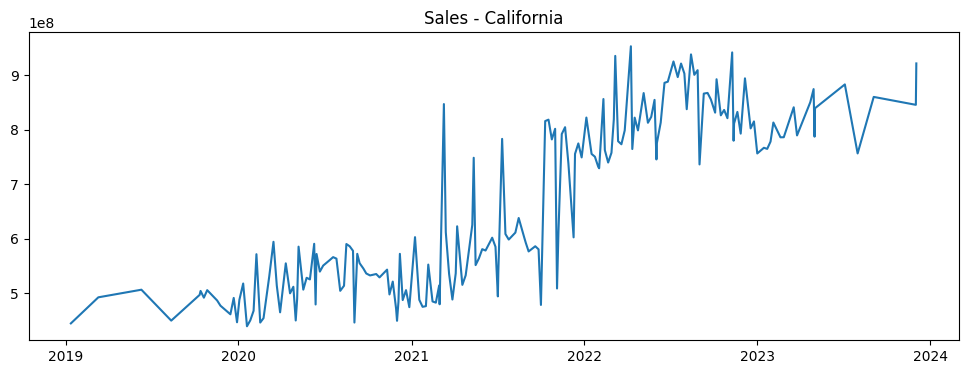

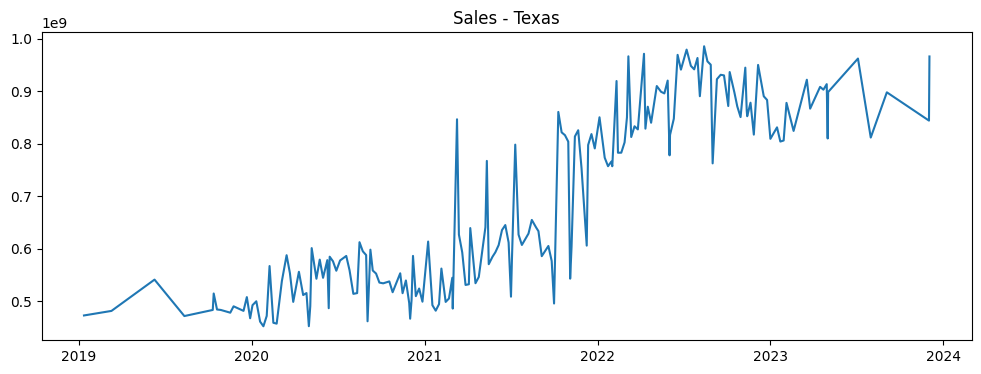

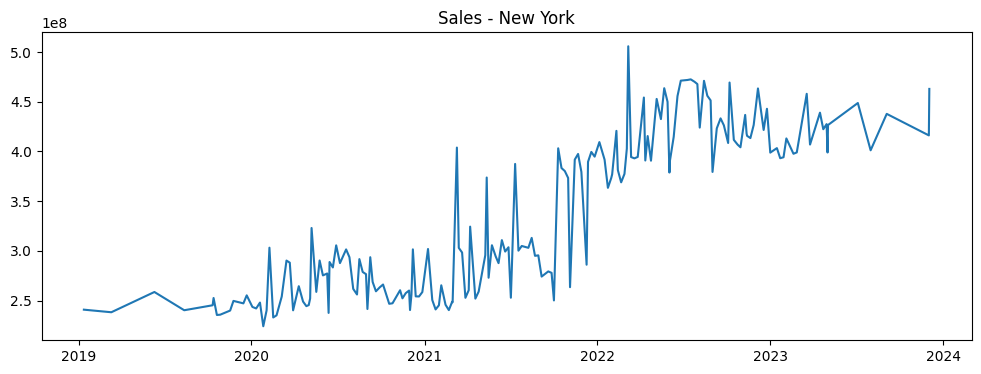

In [36]:
states_sample = ['California', 'Texas', 'New York']
for state in states_sample:
    temp = df_filled[df_filled['State']==state].set_index('Date')['Total']
    plt.figure(figsize=(12,4))
    plt.plot(temp)
    plt.title(f'Sales - {state}')
    plt.show()

Feature Engineering

In [37]:
import holidays
us_holidays = holidays.US()

def create_features(df_state):
    # df_state already has a 'State' column (when called manually)
    df_state = df_state.copy()
    # Your feature engineering code:
    df_state['dayofweek'] = df_state['Date'].dt.dayofweek
    df_state['month'] = df_state['Date'].dt.month
    df_state['dayofyear'] = df_state['Date'].dt.dayofyear
    df_state['is_holiday'] = df_state['Date'].apply(lambda x: 1 if x in us_holidays else 0)
    
    df_state['lag1'] = df_state['Total'].shift(1)
    df_state['lag7'] = df_state['Total'].shift(7)
    df_state['lag30'] = df_state['Total'].shift(30)
    
    df_state['rolling_mean_7'] = df_state['Total'].rolling(7).mean()
    df_state['rolling_std_7'] = df_state['Total'].rolling(7).std()
    df_state['rolling_mean_30'] = df_state['Total'].rolling(30).mean()
    df_state['rolling_std_30'] = df_state['Total'].rolling(30).std()
    
    df_state = df_state.dropna()  # remove rows with NaN from lags/rolling
    return df_state

import holidays
us_holidays = holidays.US()

df_feat_list = []
for state in df_filled['State'].unique():
    state_df = df_filled[df_filled['State'] == state].copy()
    state_df = create_features(state_df)
    df_feat_list.append(state_df)

df_feat = pd.concat(df_feat_list, ignore_index=True)
print(df_feat.columns.tolist())  # Should include 'State'

['Date', 'State', 'Total', 'Category', 'dayofweek', 'month', 'dayofyear', 'is_holiday', 'lag1', 'lag7', 'lag30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'rolling_std_30']


Train/Validation Split (Time Series Cross-Validation)

In [38]:
def train_val_split(df_state, val_days=56):
    df_state = df_state.sort_values('Date')
    split_date = df_state['Date'].max() - timedelta(days=val_days)
    train = df_state[df_state['Date'] < split_date]
    val = df_state[df_state['Date'] >= split_date]
    return train, val

# Test with California
state_data = df_feat[df_feat['State']=='California']
train, val = train_val_split(state_data)
print(f"Train size: {len(train)}, Val size: {len(val)}")

Train size: 1700, Val size: 57


Implement Models

SARIMA

In [39]:
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error

def fit_sarima(series):
    model = auto_arima(series, seasonal=True, m=7,
                       start_p=0, start_q=0, max_p=5, max_q=5,
                       start_P=0, start_Q=0, max_P=2, max_Q=2,
                       error_action='ignore', suppress_warnings=True, stepwise=True)
    return model

# Example training
train_series = train.set_index('Date')['Total']
sarima_model = fit_sarima(train_series)
sarima_pred = sarima_model.predict(n_periods=len(val))
rmse_sarima = np.sqrt(mean_squared_error(val['Total'], sarima_pred))
print(f"SARIMA RMSE: {rmse_sarima}")

SARIMA RMSE: 10314252.45429064


Facebook Prophet

In [40]:
from prophet import Prophet

def fit_prophet(train_df):
    df_prophet = train_df[['Date', 'Total']].rename(columns={'Date':'ds', 'Total':'y'})
    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model.add_country_holidays(country_name='US')
    model.fit(df_prophet)
    return model

def predict_prophet(model, periods):
    future = model.make_future_dataframe(periods=periods, include_history=False)
    forecast = model.predict(future)
    return forecast['yhat'].values

prophet_model = fit_prophet(train)
prophet_pred = predict_prophet(prophet_model, len(val))
rmse_prophet = np.sqrt(mean_squared_error(val['Total'], prophet_pred))
print(f"Prophet RMSE: {rmse_prophet}")

Importing plotly failed. Interactive plots will not work.
15:39:18 - cmdstanpy - INFO - Chain [1] start processing
15:39:20 - cmdstanpy - INFO - Chain [1] done processing


Prophet RMSE: 33603318.541109316


XGBoost with Lag Features

In [41]:
import xgboost as xgb

feature_cols = ['lag1', 'lag7', 'lag30', 'rolling_mean_7', 'rolling_std_7',
                'rolling_mean_30', 'rolling_std_30', 'dayofweek', 'month', 'is_holiday']

def fit_xgboost(train_df):
    X_train = train_df[feature_cols]
    y_train = train_df['Total']
    model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
    model.fit(X_train, y_train)
    return model

xgb_model = fit_xgboost(train)
X_val = val[feature_cols]
xgb_pred = xgb_model.predict(X_val)
rmse_xgb = np.sqrt(mean_squared_error(val['Total'], xgb_pred))
print(f"XGBoost RMSE: {rmse_xgb}")

XGBoost RMSE: 10321494.2806266


LSTM (Deep Learning)

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

def prepare_lstm_data(series, lookback=30):
    X, y = [], []
    for i in range(lookback, len(series)):
        X.append(series[i-lookback:i])
        y.append(series[i])
    return np.array(X), np.array(y)

def fit_lstm(train_series):
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(train_series.values.reshape(-1,1))
    X, y = prepare_lstm_data(scaled.flatten(), lookback=30)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    model = Sequential()
    model.add(LSTM(64, activation='relu', input_shape=(30,1)))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    model.fit(X, y, epochs=20, batch_size=32, verbose=0)
    return model, scaler

def predict_lstm(model, scaler, last_30_actual, steps):
    predictions = []
    current_seq = last_30_actual.copy()
    for _ in range(steps):
        scaled_seq = scaler.transform(current_seq.reshape(-1,1)).flatten()
        X_pred = scaled_seq[-30:].reshape((1,30,1))
        pred_scaled = model.predict(X_pred, verbose=0)[0,0]
        pred = scaler.inverse_transform([[pred_scaled]])[0,0]
        predictions.append(pred)
        current_seq = np.append(current_seq[1:], pred)
    return predictions

lstm_model, scaler = fit_lstm(train['Total'])
last_30 = train['Total'].values[-30:]
lstm_pred = predict_lstm(lstm_model, scaler, last_30, len(val))
rmse_lstm = np.sqrt(mean_squared_error(val['Total'], lstm_pred))
print(f"LSTM RMSE: {rmse_lstm}")

LSTM RMSE: 87225809.14798202


Model Comparison & Selection

In [43]:
results = {
    'SARIMA': rmse_sarima,
    'Prophet': rmse_prophet,
    'XGBoost': rmse_xgb,
    'LSTM': rmse_lstm
}
best_model = min(results, key=results.get)
print(f"Best model for California: {best_model} with RMSE {results[best_model]:.2f}")

# Store best model globally (we'll retrain later on full data)

Best model for California: SARIMA with RMSE 10314252.45


Retrain Best Model on Full Data & Forecast 8 Weeks

15:39:44 - cmdstanpy - INFO - Chain [1] start processing
15:39:44 - cmdstanpy - INFO - Chain [1] done processing


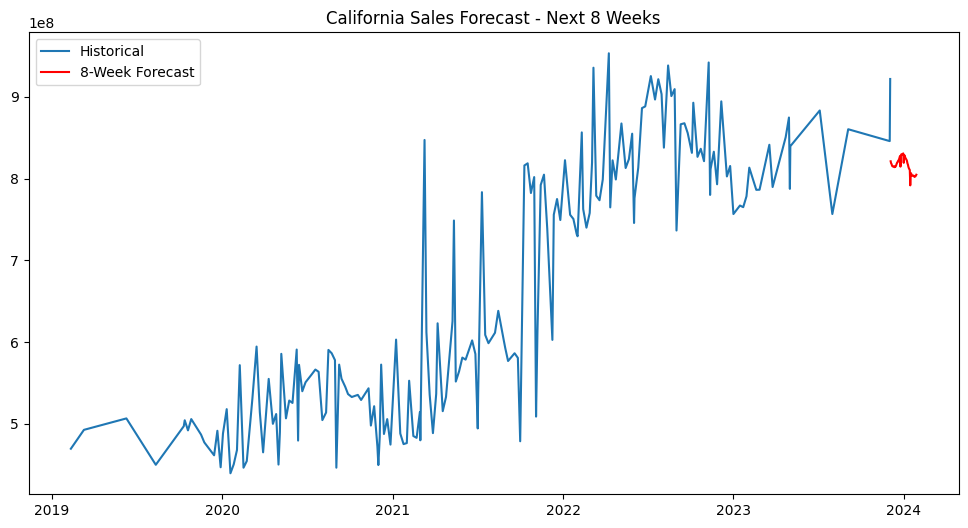

In [44]:
# Example: if best_model == 'Prophet'
full_data = state_data  # state_data is already the whole dataset for California
prophet_full = fit_prophet(full_data)
future_forecast = predict_prophet(prophet_full, 56)  # 56 days = 8 weeks
forecast_dates = pd.date_range(full_data['Date'].max() + timedelta(days=1), periods=56, freq='D')

# Plot
plt.figure(figsize=(12,6))
plt.plot(full_data['Date'], full_data['Total'], label='Historical')
plt.plot(forecast_dates, future_forecast, label='8-Week Forecast', color='red')
plt.title('California Sales Forecast - Next 8 Weeks')
plt.legend()
plt.show()

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from pmdarima import auto_arima
from prophet import Prophet
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

os.makedirs('models', exist_ok=True)

# Define feature columns (same as in your feature engineering)
feature_cols = ['lag1', 'lag7', 'lag30', 'rolling_mean_7', 'rolling_std_7',
                'rolling_mean_30', 'rolling_std_30', 'dayofweek', 'month', 'is_holiday']

# Helper function to prepare LSTM data
def prepare_lstm_data(series, lookback=30):
    X, y = [], []
    for i in range(lookback, len(series)):
        X.append(series[i-lookback:i])
        y.append(series[i])
    return np.array(X), np.array(y)

# Function to fit LSTM (returns model and scaler)
def fit_lstm(series):
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(series.values.reshape(-1, 1))
    X, y = prepare_lstm_data(scaled.flatten(), 30)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    model = Sequential()
    model.add(LSTM(64, activation='relu', input_shape=(30, 1)))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    model.fit(X, y, epochs=20, batch_size=32, verbose=0)
    return model, scaler

# Function to predict LSTM
def predict_lstm(model, scaler, last_30, steps):
    predictions = []
    current = last_30.copy()
    for _ in range(steps):
        scaled_seq = scaler.transform(current.reshape(-1, 1)).flatten()
        X_pred = scaled_seq[-30:].reshape((1, 30, 1))
        pred_scaled = model.predict(X_pred, verbose=0)[0, 0]
        pred = scaler.inverse_transform([[pred_scaled]])[0, 0]
        predictions.append(pred)
        current = np.append(current[1:], pred)
    return np.array(predictions)

# Loop over all states
for state in df_feat['State'].unique():
    print(f"\n=== Processing {state} ===")
    state_data = df_feat[df_feat['State'] == state].sort_values('Date')
    train, val = train_val_split(state_data)  # your function
    
    # --- 1. SARIMA ---
    train_series = train.set_index('Date')['Total']
    sarima_model = auto_arima(train_series, seasonal=True, m=7,
                              start_p=0, start_q=0, max_p=5, max_q=5,
                              start_P=0, start_Q=0, max_P=2, max_Q=2,
                              error_action='ignore', suppress_warnings=True,
                              stepwise=True)
    sarima_pred = sarima_model.predict(n_periods=len(val))
    rmse_sarima = np.sqrt(mean_squared_error(val['Total'], sarima_pred))
    
    # --- 2. Prophet ---
    prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
    prophet_model.add_country_holidays(country_name='US')
    prophet_train = train[['Date', 'Total']].rename(columns={'Date':'ds', 'Total':'y'})
    prophet_model.fit(prophet_train)
    future = prophet_model.make_future_dataframe(periods=len(val), include_history=False)
    prophet_pred = prophet_model.predict(future)['yhat'].values
    rmse_prophet = np.sqrt(mean_squared_error(val['Total'], prophet_pred))
    
    # --- 3. XGBoost ---
    xgb_model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
    xgb_model.fit(train[feature_cols], train['Total'])
    xgb_pred = xgb_model.predict(val[feature_cols])
    rmse_xgb = np.sqrt(mean_squared_error(val['Total'], xgb_pred))
    
    # --- 4. LSTM ---
    lstm_model, lstm_scaler = fit_lstm(train['Total'])
    last_30 = train['Total'].values[-30:]
    lstm_pred = predict_lstm(lstm_model, lstm_scaler, last_30, len(val))
    rmse_lstm = np.sqrt(mean_squared_error(val['Total'], lstm_pred))
    
    # --- Compare and select best ---
    results = {
        'SARIMA': rmse_sarima,
        'Prophet': rmse_prophet,
        'XGBoost': rmse_xgb,
        'LSTM': rmse_lstm
    }
    best_model_name = min(results, key=results.get)
    print(f"Best model for {state}: {best_model_name} (RMSE: {results[best_model_name]:.2f})")
    
    # --- Retrain best model on FULL data (train+val) ---
    full_data = pd.concat([train, val], ignore_index=True).sort_values('Date')
    
    if best_model_name == 'SARIMA':
        full_series = full_data.set_index('Date')['Total']
        best_model = auto_arima(full_series, seasonal=True, m=7,
                                 start_p=0, start_q=0, max_p=5, max_q=5,
                                 start_P=0, start_Q=0, max_P=2, max_Q=2,
                                 error_action='ignore', suppress_warnings=True,
                                 stepwise=True)
        joblib.dump(best_model, f"models/{state}_best.pkl")
        
    elif best_model_name == 'Prophet':
        best_model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
        best_model.add_country_holidays(country_name='US')
        full_prophet = full_data[['Date', 'Total']].rename(columns={'Date':'ds', 'Total':'y'})
        best_model.fit(full_prophet)
        joblib.dump(best_model, f"models/{state}_best.pkl")
        
    elif best_model_name == 'XGBoost':
        best_model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
        best_model.fit(full_data[feature_cols], full_data['Total'])
        joblib.dump(best_model, f"models/{state}_best.pkl")
        
    else:  # LSTM
        model, scaler = fit_lstm(full_data['Total'])
        joblib.dump({'model': model, 'scaler': scaler}, f"models/{state}_best.pkl")
    
    print(f"Saved model for {state}")

print("\n✅ All states processed and models saved.")


=== Processing Alabama ===


15:46:32 - cmdstanpy - INFO - Chain [1] start processing
15:46:32 - cmdstanpy - INFO - Chain [1] done processing


Best model for Alabama: XGBoost (RMSE: 3186720.05)
Saved model for Alabama

=== Processing Arizona ===


15:47:34 - cmdstanpy - INFO - Chain [1] start processing
15:47:34 - cmdstanpy - INFO - Chain [1] done processing


Best model for Arizona: XGBoost (RMSE: 3356954.01)
Saved model for Arizona

=== Processing Arkansas ===


15:48:25 - cmdstanpy - INFO - Chain [1] start processing
15:48:26 - cmdstanpy - INFO - Chain [1] done processing


Best model for Arkansas: XGBoost (RMSE: 1899886.07)
Saved model for Arkansas

=== Processing California ===


15:48:56 - cmdstanpy - INFO - Chain [1] start processing
15:48:57 - cmdstanpy - INFO - Chain [1] done processing


Best model for California: SARIMA (RMSE: 10314252.45)


KeyboardInterrupt: 

In [47]:
import joblib
for state in ['Alabama', 'Arizona', 'Arkansas', 'California']:
    state_data = df_feat[df_feat['State'] == state].sort_values('Date')
    last_row = state_data.iloc[-1:].copy()
    joblib.dump(last_row, f"models/{state}_initial_state.pkl")
    print(f"Saved initial state for {state}")

Saved initial state for Alabama
Saved initial state for Arizona
Saved initial state for Arkansas
Saved initial state for California
